
# Avaliação Prática — Fundamentos de Pandas (Módulo 3)

Esta avaliação contém **10 questões** de nível introdutório sobre **Pandas** e **análise de dados**.
O foco é demonstrar domínio das operações básicas de **importação**, **inspeção** e **manipulação simples** de DataFrames.

**Instruções gerais:**
- Responda **apenas** nas células de código logo abaixo de cada enunciado.
- Execute a célula **Setup** antes de começar.
- Utilize o arquivo CSV fornecido: **`avaliacao_empresa.csv`** (na mesma pasta deste notebook).

In [2]:

# Setup (execute esta célula primeiro — não alterar)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 30)
pd.set_option("display.max_columns", 30)
print("Ambiente pronto.")


Ambiente pronto.


### Questão 1) Importe o arquivo CSV e crie um DataFrame chamado `df`.

In [3]:
df = pd.read_csv("avaliacao_empresa.csv")

### Questão 2) Mostre os **5 primeiros** elementos do DataFrame.

In [4]:
print("Questão 2:")
print(df.head())

Questão 2:
   id_funcionario    nome departamento  turno     cidade        data  \
0               2   Bruno    Operacoes  Tarde   Campinas  2025-01-01   
1               3   Carla           TI  Noite  Sao Paulo  2025-01-08   
2               4   Diego       Vendas  Manha   Campinas  2025-01-15   
3               5  Elaine    Operacoes  Tarde  Sao Paulo  2025-01-22   
4               6   Fabio           TI  Noite   Campinas  2025-01-29   

   vendas_qtd  ticket_medio  faturamento     custo     lucro  \
0          56         975.0      54600.0  41435.15  13164.85   
1          50         415.0      20750.0  10791.38   9958.62   
2          55         107.0       5885.0   4287.17   1597.83   
3          11         755.0       8305.0   4328.67   3976.33   
4          44         456.0      20064.0  11597.60   8466.40   

   horas_trabalhadas  salario  
0                166     8086  
1                142     8703  
2                130     8221  
3                147     4954  
4          

### Questão 3) Exiba as **informações gerais** do DataFrame (tipos de dados e nulos).

In [5]:
print("\nquestão 3:")


questão 3:


### Questão 4) Mostre o **formato (linhas, colunas)** e a **lista de colunas** do DataFrame.

In [6]:
print(df.shape)
print(df.columns)

(26, 13)
Index(['id_funcionario', 'nome', 'departamento', 'turno', 'cidade', 'data',
       'vendas_qtd', 'ticket_medio', 'faturamento', 'custo', 'lucro',
       'horas_trabalhadas', 'salario'],
      dtype='str')


### Questão 5) Exiba as **estatísticas descritivas** das colunas numéricas (média, min, max, etc.).

In [7]:
print(df.describe())

       id_funcionario  vendas_qtd  ticket_medio   faturamento         custo  \
count       26.000000   26.000000     26.000000     26.000000     26.000000   
mean         9.115385   36.230769    704.461538  24709.769231  16113.651154   
std          5.826333   16.307808    357.249966  18055.721968  13710.279075   
min          1.000000    7.000000    107.000000   3690.000000   2035.920000   
25%          4.250000   27.500000    404.500000  12385.250000   6811.280000   
50%          7.500000   40.500000    709.000000  20244.000000  10845.565000   
75%         13.750000   49.750000    944.500000  34814.500000  23857.580000   
max         20.000000   57.000000   1384.000000  67816.000000  50905.520000   

              lucro  horas_trabalhadas      salario  
count     26.000000          26.000000    26.000000  
mean    8596.118077         161.384615  6528.846154  
std     5829.027283          21.183157  1829.020824  
min     1192.560000         121.000000  3274.000000  
25%     4104.26250

### Questão 6) Selecione apenas as colunas `nome` e `departamento` e mostre as **5 primeiras** linhas.

In [9]:
print(df[['nome', 'departamento']].head())

     nome departamento
0   Bruno    Operacoes
1   Carla           TI
2   Diego       Vendas
3  Elaine    Operacoes
4   Fabio           TI


### Questão 7) Filtre os registros do **turno 'Noite'** e **conte** quantos registros existem.

In [11]:
df[df['turno'] == 'noite'].shape[0]

0

### Questão 8) O código abaixo converte as datas de texto para data e em seguida cria uma coluna mês para os dados.
Mostre as **5 primeiras** linhas de `df[['data','mes']]`.

In [12]:
df['data']=pd.to_datetime(df['data'],errors='coerce')
df['mes']=df['data'].dt.to_period('M').astype(str)

#Insira o seu código aqui
df[['data','mes']].head()

,data,mes
0,2025-01-01,2025-01
1,2025-01-08,2025-01
2,2025-01-15,2025-01
3,2025-01-22,2025-01
4,2025-01-29,2025-01


### Questão 9) O código abaixo agrupa e soma os valores por mes no DataFrame fat.
Mostre os **3 meses** com maior faturamento.

In [14]:
fat = df.groupby('mes',as_index=False)['faturamento'].sum()
fat.sort_values('faturamento', ascending=False).head(3)

,mes,faturamento
5,2025-06,135267.0
2,2025-03,113759.0
0,2025-01,109604.0


### Questão 10) Calcule a **média de salário por departamento** e mostre em **ordem decrescente**.

In [15]:
#df.groupby('departamento',as_index=False)['salario'].mean().sort_values('salario',ascending=False)
salarios_por_departamento = df.groupby('departamento',as_index=False)['salario']
df.groupby('departamento', as_index=False)['salario'].mean().sort_values('salario', ascending=False)

,departamento,salario
1,TI,6795.444444
2,Vendas,6554.875000
0,Operacoes,6239.111111



---
## Extra (não avaliativo) — Demonstração de visualização

O gráfico abaixo mostra a **distribuição do faturamento por mês e por departamento** (barras empilhadas).  
**Ação do aluno:** **apenas execute** a célula para observar o resultado e refletir sobre variações por mês e por área.


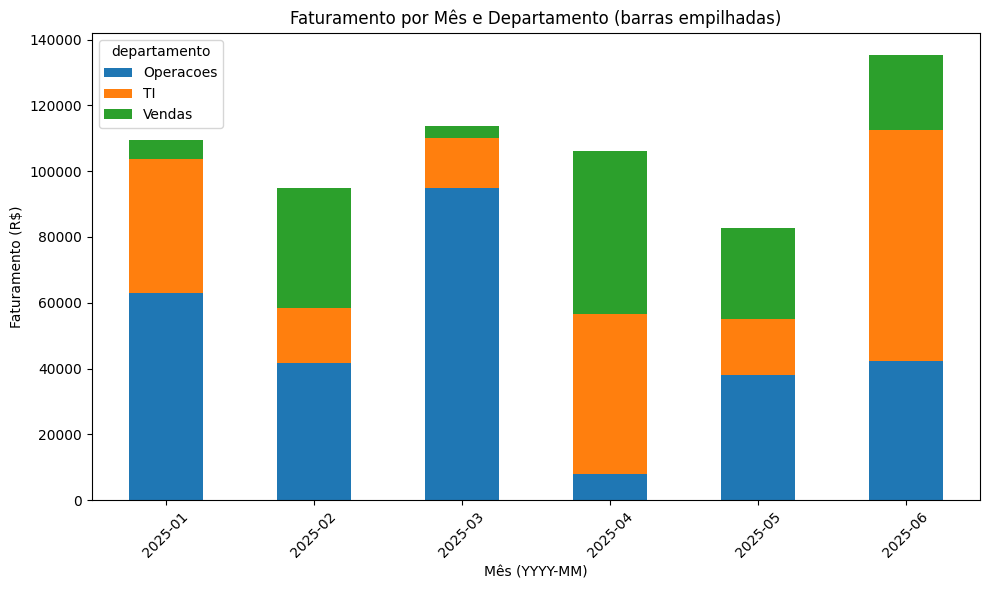

In [16]:

# ▶️ Execute esta célula (não alterar o código)
# Pré-requisitos: df já carregado; coluna 'data' convertida; coluna 'mes' criada (Questões 1 e 8).
df['data'] = pd.to_datetime(df['data'], errors='coerce')
df['mes'] = df['data'].dt.to_period('M').astype(str)

fat_mes_dep = df.groupby(['mes','departamento'], as_index=False)['faturamento'].sum()
pivot = fat_mes_dep.pivot(index='mes', columns='departamento', values='faturamento').fillna(0)

ax = pivot.plot(kind='bar', stacked=True, figsize=(10,6))
ax.set_title("Faturamento por Mês e Departamento (barras empilhadas)")
ax.set_xlabel("Mês (YYYY-MM)")
ax.set_ylabel("Faturamento (R$)")
import matplotlib.pyplot as plt
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
